<a href="https://colab.research.google.com/github/Himanshu0518/Traffic-demand-prediction/blob/main/notebooks/01_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [70]:
df = pd.read_csv('/content/train.csv')
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57366 entries, 0 to 57365
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          57366 non-null  int64  
 1   geohash        57366 non-null  object 
 2   day            57366 non-null  int64  
 3   timestamp      57366 non-null  object 
 4   demand         57366 non-null  float64
 5   RoadType       56921 non-null  object 
 6   NumberofLanes  57366 non-null  int64  
 7   LargeVehicles  57366 non-null  object 
 8   Landmarks      57366 non-null  object 
 9   Temperature    55513 non-null  float64
 10  Weather        56773 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 4.8+ MB


In [72]:
df.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,445
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,1853


In [73]:
df['Weather'].value_counts()

,count
Weather,
Sunny,20623
Rainy,15399
Foggy,15006
Snowy,5745


In [74]:
df.shape

(57366, 11)

In [75]:
df.nunique()

,0
Index,57366
geohash,1236
day,1
timestamp,70
demand,56860
RoadType,3
NumberofLanes,5
LargeVehicles,2
Landmarks,2
Temperature,55513


In [76]:
!pip install pygeohash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.4 MB/s eta 0:00:00


In [77]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPLETE FEATURE EXTRACTION PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import pygeohash as pgh
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder


# ─────────────────────────────────────────────────────────────────────────────
# 1. TIMESTAMP FEATURES  (fixes your original class)
# ─────────────────────────────────────────────────────────────────────────────

class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    FIX: pd.to_datetime(format='%H:%M') crashes on '0:0' / '9:5' style strings.
    We parse hour/minute manually instead.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # ── FIXED: manual split handles '0:0', '9:05', '23:0' etc. ──────────
        parts        = X['timestamp'].astype(str).str.split(':', expand=True)
        X['hour']    = parts[0].astype(int)
        X['minute']  = parts[1].astype(int)

        # cyclical encoding so hour 23 ≈ hour 0 in feature space
        X['hour_sin']   = np.sin(2 * np.pi * X['hour']   / 24)
        X['hour_cos']   = np.cos(2 * np.pi * X['hour']   / 24)
        X['minute_sin'] = np.sin(2 * np.pi * X['minute'] / 60)
        X['minute_cos'] = np.cos(2 * np.pi * X['minute'] / 60)

        # time-of-day bucket (useful as a raw categorical too)
        X['time_bucket'] = pd.cut(
            X['hour'],
            bins   = [-1, 5, 9, 12, 17, 20, 23],
            labels = ['night','morning_rush','midday','evening_rush','evening','late']
        ).astype(str)

        X = X.drop(columns=['timestamp'])
        return X


# ─────────────────────────────────────────────────────────────────────────────
# 2. GEOHASH FEATURES
# ─────────────────────────────────────────────────────────────────────────────

class GeohashFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Decodes geohash → lat/lon, builds prefix hierarchy,
    and computes distance to the dataset centroid.
    NOTE: group aggregations and target encoding are handled separately
          in GeohashAggregator (must be fit only on train fold).
    """

    def fit(self, X, y=None):
        coords       = X['geohash'].apply(lambda g: pgh.decode(g))
        lats         = coords.apply(lambda c: c[0])
        lons         = coords.apply(lambda c: c[1])
        self.city_lat_ = lats.mean()
        self.city_lon_ = lons.mean()
        return self

    def transform(self, X):
        X = X.copy()

        coords      = X['geohash'].apply(lambda g: pgh.decode(g))
        X['lat']    = coords.apply(lambda c: c[0])
        X['lon']    = coords.apply(lambda c: c[1])

        # prefix hierarchy  →  coarser spatial regions
        X['gh_4']   = X['geohash'].str[:4]   # ~40 km region
        X['gh_5']   = X['geohash'].str[:5]   # ~5  km region
        # full geohash[:6] kept for aggregation / target encoding

        # distance to dataset centroid (km)
        X['dist_to_center'] = X.apply(
            lambda r: self._haversine(r.lat, r.lon, self.city_lat_, self.city_lon_),
            axis=1
        )

        return X

    @staticmethod
    def _haversine(lat1, lon1, lat2, lon2):
        from math import radians, sin, cos, sqrt, atan2
        R = 6371
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a    = (sin(dlat/2)**2
                + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2)
        return R * 2 * atan2(sqrt(a), sqrt(1 - a))


# ─────────────────────────────────────────────────────────────────────────────
# 3. GEOHASH GROUP AGGREGATIONS  (fit on train only — leakage-safe)
# ─────────────────────────────────────────────────────────────────────────────

class GeohashAggregator(BaseEstimator, TransformerMixin):
    """
    Computes mean/std demand grouped by (geohash × hour) and (geohash).
    Must be fit on train fold only, then transform applied to val/test.
    Requires 'hour' column to already exist (run DateFeatureExtractor first).
    """

    def fit(self, X, y):
        Xy = X.copy()
        Xy['__demand'] = y

        # geohash × hour stats
        self.gh_hour_stats_ = (
            Xy.groupby(['geohash', 'hour'])['__demand']
              .agg(gh_hour_mean='mean', gh_hour_std='std', gh_hour_count='count')
              .reset_index()
        )

        # unconditional geohash mean
        self.gh_mean_ = (
            Xy.groupby('geohash')['__demand']
              .mean()
              .rename('gh_mean')
        )

        # global fallback for unseen geohashes at inference
        self.global_mean_ = float(y.mean())
        return self

    def transform(self, X):
        X = X.copy()

        X = X.merge(self.gh_hour_stats_, on=['geohash', 'hour'], how='left')
        X = X.join(self.gh_mean_, on='geohash')

        # fill std NaN (single-row groups) and unseen geohashes
        X['gh_hour_std']   = X['gh_hour_std'].fillna(0)
        X['gh_hour_mean']  = X['gh_hour_mean'].fillna(self.global_mean_)
        X['gh_mean']       = X['gh_mean'].fillna(self.global_mean_)
        X['gh_hour_count'] = X['gh_hour_count'].fillna(0)

        return X


# ─────────────────────────────────────────────────────────────────────────────
# 4. CATEGORICAL FEATURES  (RoadType, Weather, LargeVehicles, Landmarks)
# ─────────────────────────────────────────────────────────────────────────────

class CategoricalFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Ordinal-encodes the 4 categorical columns.
    Unknown categories at inference get -1, then filled with mode.
    """

    CAT_COLS = ['RoadType', 'Weather', 'LargeVehicles', 'Landmarks']

    def fit(self, X, y=None):
        self.encoders_ = {}
        self.modes_    = {}
        for col in self.CAT_COLS:
            if col in X.columns:
                le = LabelEncoder()
                filled = X[col].fillna('Unknown').astype(str)
                le.fit(filled)
                self.encoders_[col] = le
                self.modes_[col]    = filled.mode()[0]
        return self

    def transform(self, X):
        X = X.copy()
        for col, le in self.encoders_.items():
            filled  = X[col].fillna('Unknown').astype(str)
            # handle unseen labels gracefully
            known   = set(le.classes_)
            filled  = filled.apply(lambda v: v if v in known else self.modes_[col])
            X[col]  = le.transform(filled)

        # binary convenience flags
        if 'LargeVehicles' in X.columns:
            X['large_vehicles_flag'] = (
                X['LargeVehicles'].astype(str)
                  .str.lower()
                  .str.contains('allow')
                  .astype(int)
            )
        if 'Landmarks' in X.columns:
            X['has_landmark'] = (
                X['Landmarks'].astype(str)
                  .str.lower()
                  .map({'yes': 1, 'no': 0})
                  .fillna(0)
                  .astype(int)
            )
        return X


# ─────────────────────────────────────────────────────────────────────────────
# 5. NUMERICAL FEATURES  (Temperature + NumberofLanes)
# ─────────────────────────────────────────────────────────────────────────────

class NumericalFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Imputes Temperature with median (fit on train only).
    Adds interaction: NumberofLanes × large_vehicles_flag.
    """

    def fit(self, X, y=None):
        self.temp_median_ = X['Temperature'].median()
        self.lanes_median_ = X['NumberofLanes'].median()
        return self

    def transform(self, X):
        X = X.copy()

        X['Temperature']    = X['Temperature'].fillna(self.temp_median_)
        X['NumberofLanes']  = X['NumberofLanes'].fillna(self.lanes_median_)

        # temperature bins (captures non-linear effect on traffic)
        X['temp_bin'] = pd.cut(
            X['Temperature'],
            bins   = [-np.inf, 5, 15, 25, 35, np.inf],
            labels = [0, 1, 2, 3, 4]
        ).astype(float)

        # interaction feature
        if 'large_vehicles_flag' in X.columns:
            X['lanes_x_largeveh'] = X['NumberofLanes'] * X['large_vehicles_flag']

        return X


# ─────────────────────────────────────────────────────────────────────────────
# 6. ASSEMBLE FULL PIPELINE  (leak-safe with TimeSeriesSplit)
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb



# Data Visualization

<Axes: xlabel='NumberofLanes', ylabel='demand'>

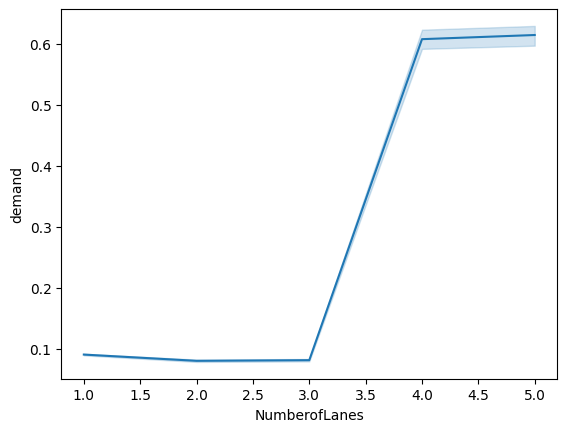

In [78]:
sns.lineplot(data=df, x='NumberofLanes', y='demand')

### Further Data Exploration

In [79]:
# Apply DateFeatureExtractor to the DataFrame for visualization
df_viz = df.copy()
date_extractor = DateFeatureExtractor()
df_viz = date_extractor.transform(df_viz)

# Display the first few rows of the transformed DataFrame to confirm new features
print("DataFrame with extracted date features:")
display(df_viz.head())

DataFrame with extracted date features:


,Index,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,minute_sin,minute_cos,time_bucket
0,0,qp02z1,48,0.048804,NaN,1,Not Allowed,No,NaN,NaN,0,0,0.0,1.0,0.0,1.0,night
1,1,qp02zt,48,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,0.0,1.0,0.0,1.0,night
2,2,qp08bj,48,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,0.0,1.0,0.0,1.0,night
3,3,qp08gt,48,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,0,0,0.0,1.0,0.0,1.0,night
4,4,qp02zq,48,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,0.0,1.0,0.0,1.0,night


### Average Demand by Hour of the Day

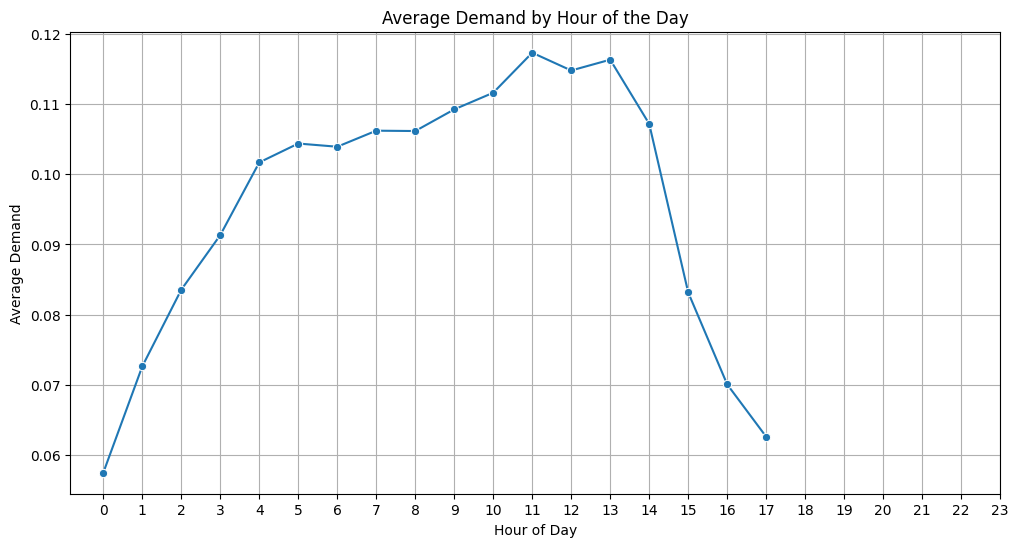

In [80]:
avg_demand_by_hour = df_viz.groupby('hour')['demand'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='demand', data=avg_demand_by_hour, marker='o')
plt.title('Average Demand by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

In [61]:
df['day'].value_counts()

,count
day,
48,57366


### Average Demand by RoadType

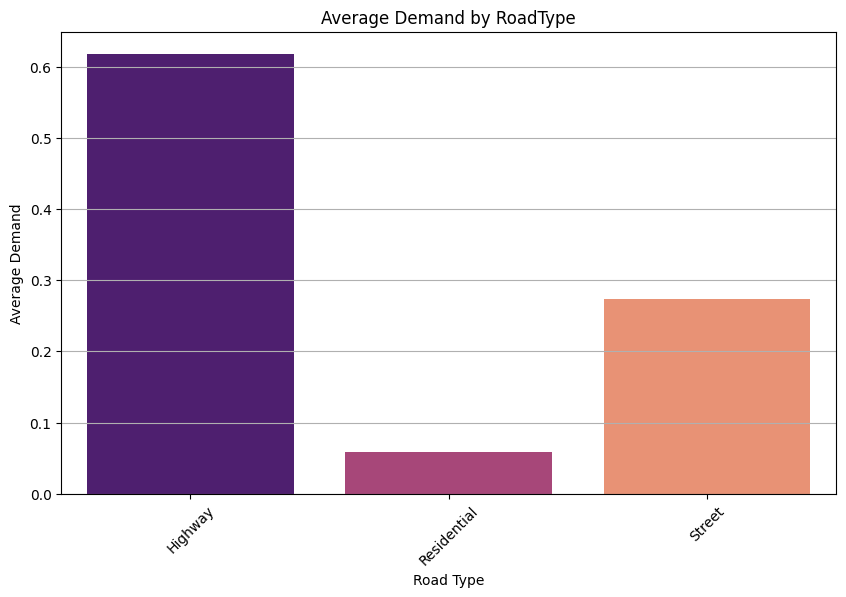

In [82]:
avg_demand_by_roadtype = df_viz.groupby('RoadType')['demand'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='RoadType', y='demand', data=avg_demand_by_roadtype, palette='magma')
plt.title('Average Demand by RoadType')
plt.xlabel('Road Type')
plt.ylabel('Average Demand')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Average Demand by Weather

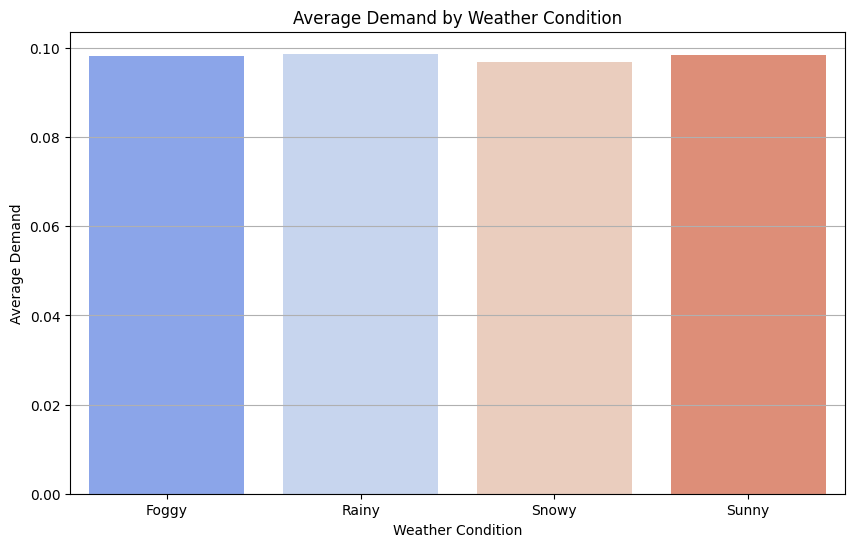

In [83]:
avg_demand_by_weather = df_viz.groupby('Weather')['demand'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Weather', y='demand', data=avg_demand_by_weather, palette='coolwarm')
plt.title('Average Demand by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Demand')
plt.grid(axis='y')
plt.show()

### Average Demand by LargeVehicles

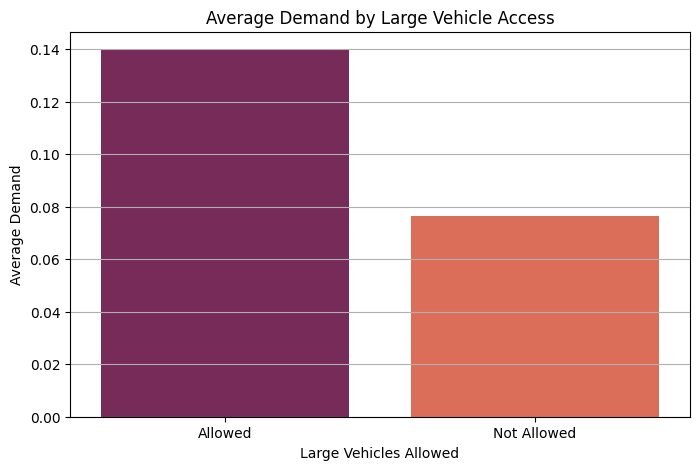

In [84]:
avg_demand_by_largevehicles = df_viz.groupby('LargeVehicles')['demand'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='LargeVehicles', y='demand', data=avg_demand_by_largevehicles, palette='rocket')
plt.title('Average Demand by Large Vehicle Access')
plt.xlabel('Large Vehicles Allowed')
plt.ylabel('Average Demand')
plt.grid(axis='y')
plt.show()

# Model Trainning pipeline

In [52]:
!#pip install catboost

In [85]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

In [36]:


# pipeline = Pipeline([
#     ('date_features', DateFeatureExtractor()),
#     ('preprocessor', preprocessor),
#     ('model', LGBMRegressor())
# ])

In [86]:
algorithms = [
     CatBoostRegressor(),
     LGBMRegressor(
      random_state=42
 )
]

In [87]:
# Split data into features (X) and target (y)
X = df.drop(['demand', 'day'], axis=1)
y = df['demand']

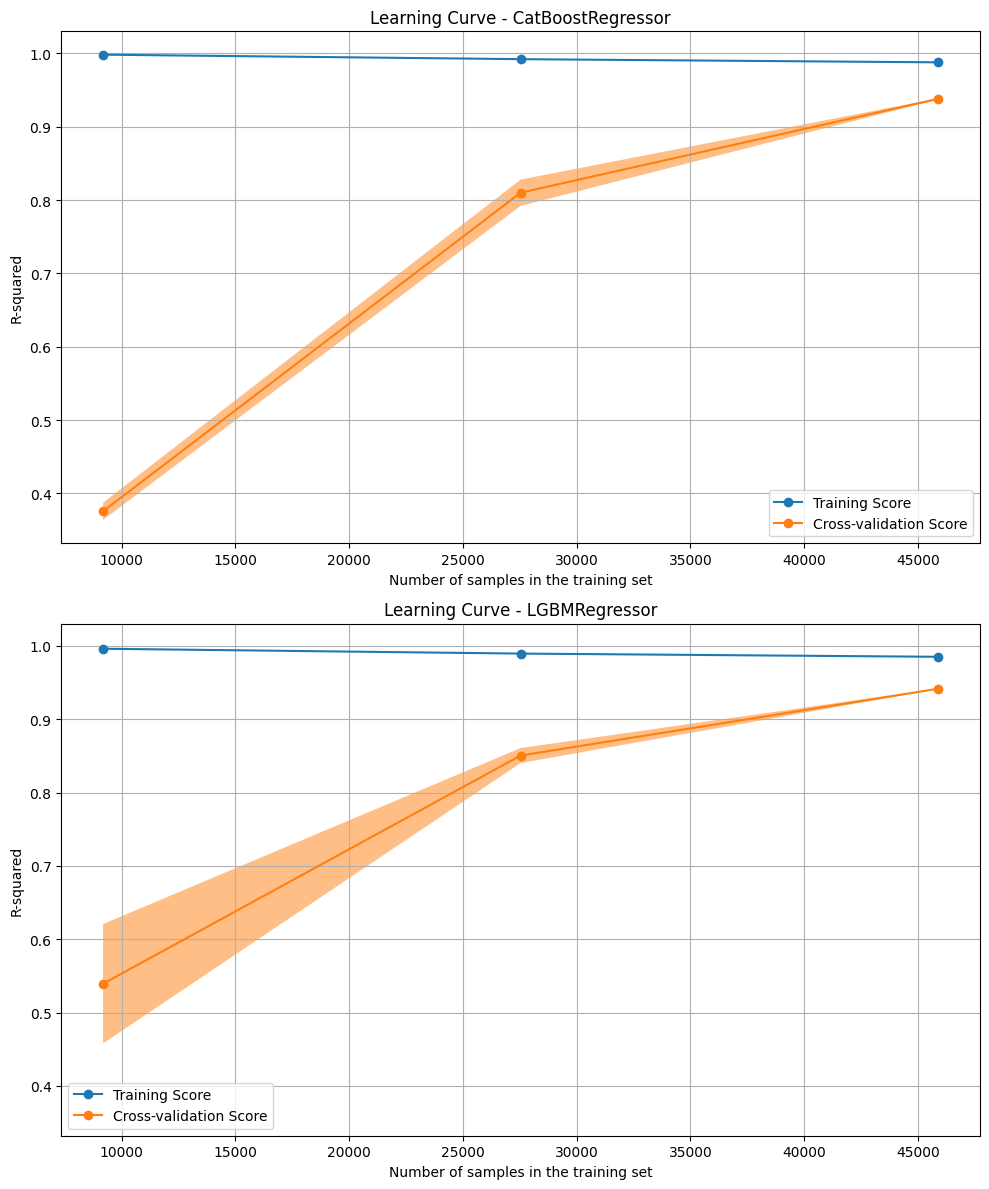

In [88]:
from sklearn.preprocessing import FunctionTransformer

# Define a custom transformer to drop columns after all feature extraction
class ColumnRemover(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_remove):
        self.columns_to_remove = columns_to_remove

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Filter out columns that might not exist yet or are already dropped
        cols_to_drop = [col for col in self.columns_to_remove if col in X_copy.columns]
        return X_copy.drop(columns=cols_to_drop, errors='ignore')

# Columns to remove before the final regressor
# These include original identifiers, geohash components, or intermediate features
# that might be redundant after full feature engineering.
columns_to_drop_final = [
    'Index', 'geohash', 'gh_4', 'gh_5',
    'time_bucket', # Use cyclical encoding instead
    'minute', # Use minute_sin/cos instead
    'lat', 'lon' # If dist_to_center is sufficient
]

num_algorithms = len(algorithms)

fig, axes = plt.subplots(
    nrows=num_algorithms,
    ncols=1,
    figsize=(10, 6 * num_algorithms),
    sharey=True
)

# If only one algorithm, convert axes to list
if num_algorithms == 1:
    axes = [axes]

common_params = {
    "X": X,
    "y": y,
    "train_sizes": np.linspace(0.2, 1.0, 3),
    "cv": ShuffleSplit(n_splits=3, test_size=0.2, random_state=0),
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "R-squared",
    "scoring": "r2"
}

for ax, model_algo in zip(axes, algorithms):
    # Build the full pipeline with all custom feature extractors
    pipeline_estimator = Pipeline([
        ('date_features', DateFeatureExtractor()),
        ('geohash_features', GeohashFeatureExtractor()),
        ('categorical_features', CategoricalFeatureExtractor()),
        ('numerical_features', NumericalFeatureExtractor()),
        ('geohash_aggregator', GeohashAggregator()),
        ('column_remover', ColumnRemover(columns_to_remove=columns_to_drop_final)),
        ('regressor', model_algo)
    ])

    LearningCurveDisplay.from_estimator(
        pipeline_estimator,
        **common_params,
        ax=ax
    )

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:2],
        ["Training Score", "Cross-validation Score"]
    )

    ax.set_title(
        f"Learning Curve - {model_algo.__class__.__name__}"
    )

    ax.grid(True)

plt.tight_layout()
plt.show()